# Week 1 — Forward Noising with 2D Blobs

## Learning Objectives

By the end of this notebook, you will:
1. Understand what a **mixture of Gaussians** ("blobs") looks like and why it's useful for toy diffusion experiments
2. Implement the **forward noising** process: `x_t = x_0 + σ(t)·ε`
3. Compare **linear vs geometric sigma schedules** and see how they affect the "wash out" of structure

## Why This Matters for Diffusion Models

Diffusion models work by:
1. **Forward process**: Gradually add noise to data until it becomes pure noise
2. **Reverse process**: Learn to undo the noise, step by step, to generate new data

Today we focus on the forward process. We'll use 2D data because we can **visualize everything** — no neural networks needed yet, just pure probability.

## Why 2D Blobs?

A mixture of Gaussians ("blobs") is:
- **Structured**: clear clusters we can see
- **Simple**: easy to generate and understand
- **Representative**: captures the key idea that data has structure which noise destroys

---
## Section 0: Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## Section 1: What is a Mixture of Gaussians?

A **mixture of Gaussians** is data that comes from several Gaussian (normal) distributions, each centered at a different location. Visually, this looks like "blobs" or clusters of points.

**Intuition:**
- Each blob is a cluster of points drawn from a 2D Gaussian
- The clusters are separated in space — this is the "structure" we'll try to destroy with noise
- Think of it as a simple stand-in for real data (images, audio, etc.) which also has structure

**Your task:** Use `sklearn.datasets.make_blobs` to generate the data.

In [4]:
# TODO: Generate 3 clusters of 2D points using sklearn's make_blobs
#
# Parameters to use:
#   n_samples: 1500 total points
#   centers: 3 clusters
#   cluster_std: 0.5 (tight clusters so we can see structure clearly)
#   random_state: 42 (for reproducibility)
#
# Hint: make_blobs returns (X, y) where X is the data and y is cluster labels

# x_0, labels = ...  # YOUR CODE HERE
x_0, labels = make_blobs(n_samples=1500, centers=3, cluster_std=0.5, random_state=42)

Data shape: (1500, 2)
Number of clusters: 3
Points per cluster: [500 500 500]


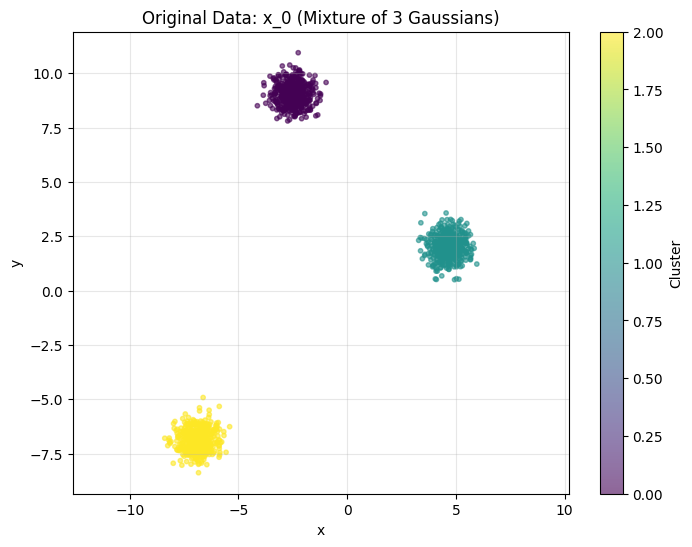

In [5]:
# Verification: Let's see what we generated
print(f"Data shape: {x_0.shape}")
print(f"Number of clusters: {len(np.unique(labels))}")
print(f"Points per cluster: {np.bincount(labels)}")

plt.figure(figsize=(8, 6))
plt.scatter(x_0[:, 0], x_0[:, 1], c=labels, cmap='viridis', alpha=0.6, s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original Data: x_0 (Mixture of 3 Gaussians)')
plt.colorbar(label='Cluster')
plt.axis('equal')
plt.show()

**Checkpoint:** You should see 3 distinct blobs. If you don't, check your `make_blobs` parameters.

---
## Section 2: The Forward Noising Process

### The Core Idea

We want to gradually **corrupt** our data by adding noise. The more noise we add, the less we can recognize the original structure.

### The Formula

$$x_t = x_0 + \sigma(t) \cdot \varepsilon$$

where:
- $x_0$ — original clean data (our blobs)
- $\sigma(t)$ — noise level at "time" $t$ (we control this with a schedule)
- $\varepsilon \sim \mathcal{N}(0, I)$ — random Gaussian noise (same shape as $x_0$)
- $x_t$ — noisy version of the data

### Why This Formula?

- **Additive noise**: we simply add noise to each point
- **$\sigma$ controls "how much"**: when $\sigma=0$, we get $x_0$ back; when $\sigma$ is large, noise dominates
- **Gaussian noise**: mathematically convenient (sums of Gaussians are Gaussian)

**Your task:** Implement the `forward_noise` function.

In [16]:
def forward_noise(x_0, sigma):
    """
    Add Gaussian noise to data points.
    
    Args:
        x_0: Original data, shape (n_samples, 2)
        sigma: Noise level (scalar)
    
    Returns:
        x_t: Noisy data, same shape as x_0
    
    Formula: x_t = x_0 + sigma * epsilon
    where epsilon ~ N(0, I)
    """
    # TODO: Sample epsilon from standard normal with same shape as x_0
    # Hint: np.random.randn(*shape) gives samples from N(0, 1)
    
    # eps = ...  # YOUR CODE HERE
    eps = np.random.randn(x_0.shape[0], x_0.shape[1])
    
    # TODO: Apply the forward noising formula
    
    # x_t = ...  # YOUR CODE HERE
    x_t = x_0 + sigma * eps
    
    return x_t

In [17]:
# Verification: Test your implementation

# Test 1: sigma=0 should return x_0 (no noise added)
np.random.seed(42)
x_test = forward_noise(x_0, sigma=0.0)
assert np.allclose(x_test, x_0), "With sigma=0, output should equal input!"
print("✓ Test 1 passed: sigma=0 returns original data")

# Test 2: sigma>0 should change the data
np.random.seed(42)
x_test = forward_noise(x_0, sigma=0.5)
assert not np.allclose(x_test, x_0), "With sigma>0, output should differ from input!"
print("✓ Test 2 passed: sigma>0 adds noise")

# Test 3: output shape should match input shape
assert x_test.shape == x_0.shape, "Output shape should match input shape!"
print("✓ Test 3 passed: shape preserved")

print("\nAll tests passed!")

✓ Test 1 passed: sigma=0 returns original data
✓ Test 2 passed: sigma>0 adds noise
✓ Test 3 passed: shape preserved

All tests passed!


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


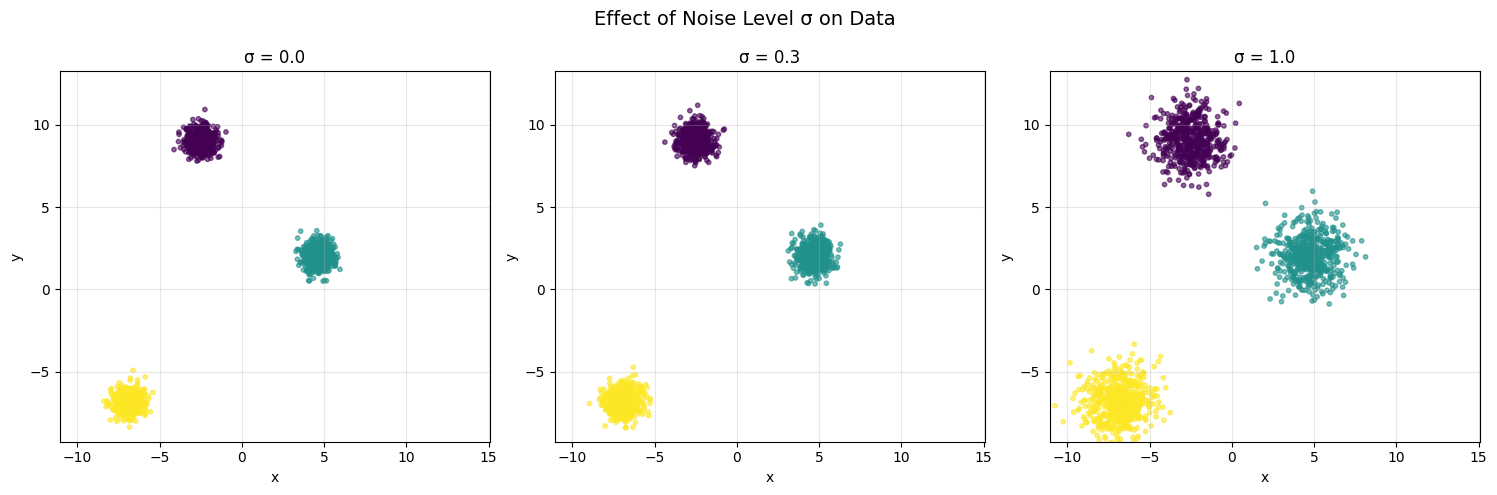

In [18]:
# Visual verification: side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sigmas = [0.0, 0.3, 1.0]

for ax, sigma in zip(axes, sigmas):
    np.random.seed(42)  # Same noise realization for comparison
    x_noised = forward_noise(x_0, sigma)
    ax.scatter(x_noised[:, 0], x_noised[:, 1], c=labels, cmap='viridis', alpha=0.6, s=10)
    ax.set_title(f'σ = {sigma}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal')
    ax.set_xlim(-8, 12)
    ax.set_ylim(-8, 12)

plt.suptitle('Effect of Noise Level σ on Data', fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** As σ increases, the clusters spread out and overlap. At σ=1.0, the structure is significantly degraded.

---
## Section 3: Sigma Schedules — Controlling the Corruption

In practice, we don't pick a single σ value. We define a **schedule** that tells us how σ changes with time $t \in [0, 1]$:

- At $t = 0$: σ is small (data is nearly clean)
- At $t = 1$: σ is large (data is nearly pure noise)

### Two Common Schedules

**1. Linear Schedule**
$$\sigma(t) = \sigma_{\min} + t \cdot (\sigma_{\max} - \sigma_{\min})$$

σ grows at a constant rate.

**2. Geometric Schedule**
$$\sigma(t) = \sigma_{\min} \cdot \left(\frac{\sigma_{\max}}{\sigma_{\min}}\right)^t$$

σ grows slowly at first, then accelerates. (This is exponential interpolation.)

### Why Does the Schedule Matter?

The schedule controls **how fast structure is destroyed**:
- Too fast → the model has fewer "easy" steps to learn
- Too slow → wasteful, many steps don't change much

**Your task:** Implement both schedules.

In [19]:
def sigma_linear(t, sigma_min=0.01, sigma_max=2.0):
    """
    Linear schedule: sigma grows linearly from sigma_min to sigma_max.
    
    Args:
        t: Time value(s) in [0, 1] (can be scalar or array)
        sigma_min: Noise level at t=0
        sigma_max: Noise level at t=1
    
    Returns:
        sigma(t)
    
    Formula: σ(t) = σ_min + t · (σ_max - σ_min)
    """
    # TODO: Implement the linear schedule
    
    # return ...  # YOUR CODE HERE
    return sigma_min + t * (sigma_max - sigma_min)

In [23]:
def sigma_geometric(t, sigma_min=0.01, sigma_max=2.0):
    """
    Geometric schedule: sigma grows exponentially.
    
    Args:
        t: Time value(s) in [0, 1] (can be scalar or array)
        sigma_min: Noise level at t=0
        sigma_max: Noise level at t=1
    
    Returns:
        sigma(t)
    
    Formula: σ(t) = σ_min · (σ_max / σ_min)^t
    """
    # TODO: Implement the geometric schedule
    # Hint: a^t = exp(t * log(a))
    
    # return ...  # YOUR CODE HERE
    return sigma_min * np.exp(t * np.log(sigma_max/sigma_min))

In [24]:
# Verification: Check boundary conditions
print("Linear schedule:")
print(f"  σ(0) = {sigma_linear(0):.4f} (should be 0.01)")
print(f"  σ(1) = {sigma_linear(1):.4f} (should be 2.00)")

print("\nGeometric schedule:")
print(f"  σ(0) = {sigma_geometric(0):.4f} (should be 0.01)")
print(f"  σ(1) = {sigma_geometric(1):.4f} (should be 2.00)")

Linear schedule:
  σ(0) = 0.0100 (should be 0.01)
  σ(1) = 2.0000 (should be 2.00)

Geometric schedule:
  σ(0) = 0.0100 (should be 0.01)
  σ(1) = 2.0000 (should be 2.00)


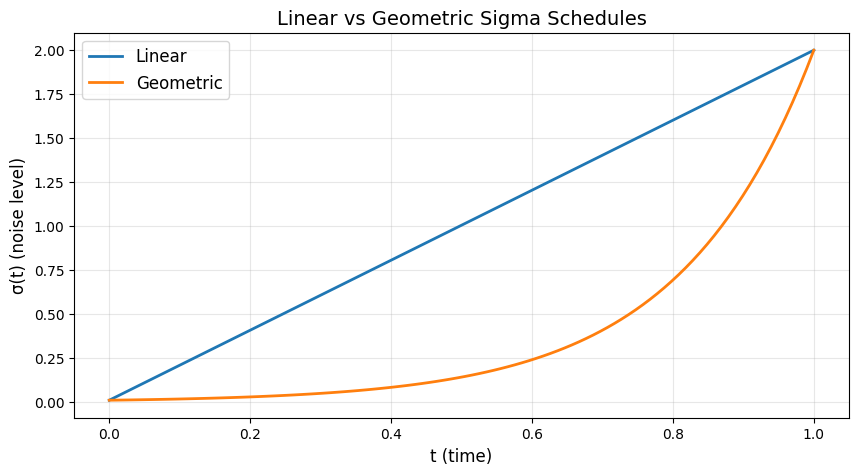

In [25]:
# Visual comparison of schedules
t_values = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 5))
plt.plot(t_values, sigma_linear(t_values), label='Linear', linewidth=2)
plt.plot(t_values, sigma_geometric(t_values), label='Geometric', linewidth=2)
plt.xlabel('t (time)', fontsize=12)
plt.ylabel('σ(t) (noise level)', fontsize=12)
plt.title('Linear vs Geometric Sigma Schedules', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

**Questions to consider:**
- Which schedule grows faster at small $t$ (near 0)?
- Which schedule grows faster at large $t$ (near 1)?
- What might this mean for how quickly structure is destroyed?

---
## Section 4: Visualizing the "Wash Out"

Now let's put it all together. We'll create a grid showing:
- **Rows**: Linear vs Geometric schedule
- **Columns**: Different timesteps (t = 0, 0.25, 0.5, 0.75, 1.0)

This will let us see **how each schedule destroys structure** over time.

**Your task:** Complete the visualization loop.

In [26]:
# Setup
timesteps = [0.0, 0.25, 0.5, 0.75, 1.0]

schedules = {
    'Linear': sigma_linear,
    'Geometric': sigma_geometric
}

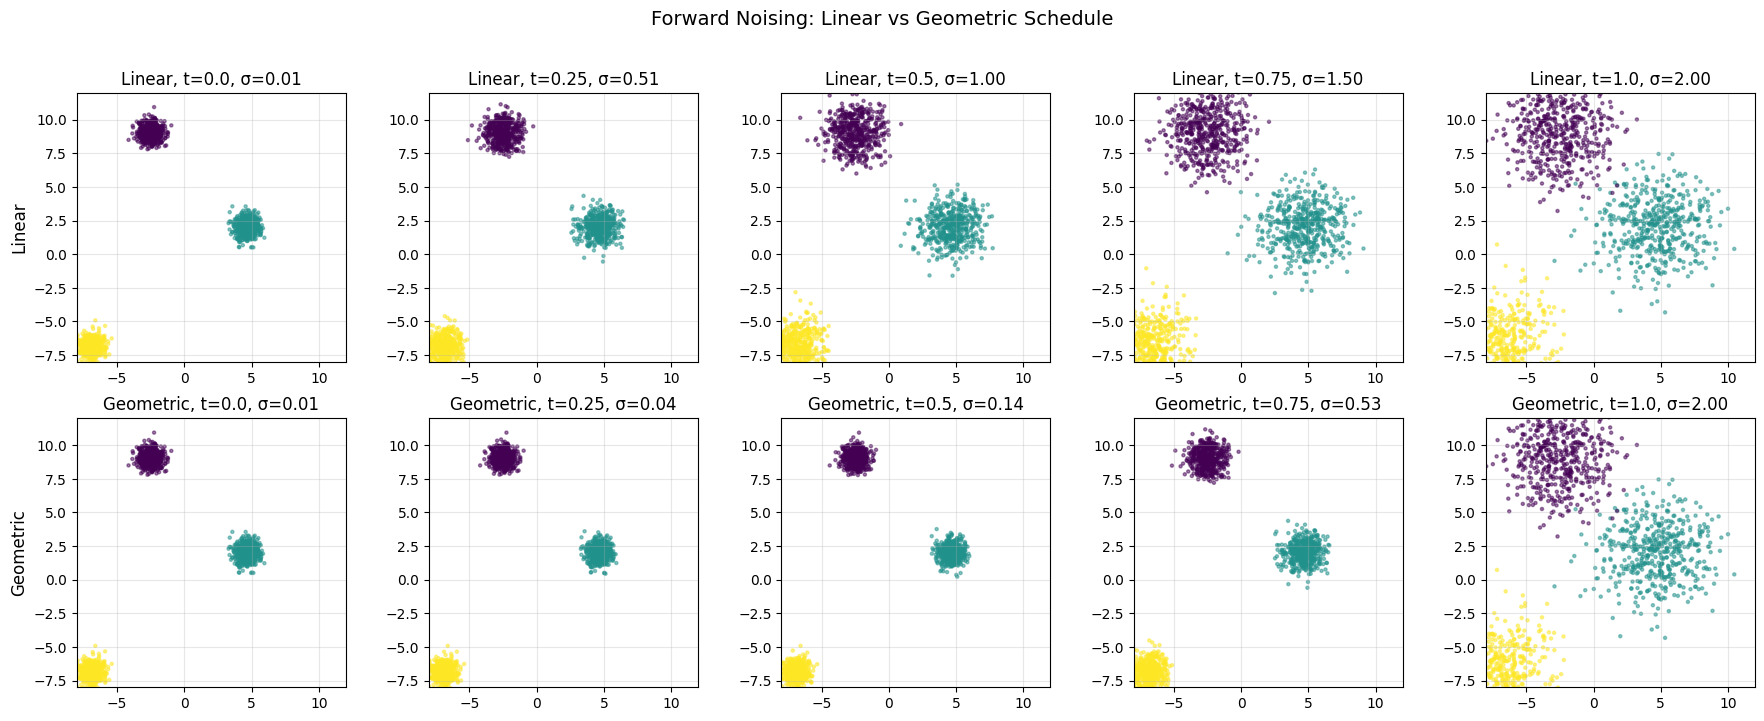


Figure saved to: notes/figures/w01_forward_noising_comparison.png


In [34]:
# TODO: Create a 2x5 grid of scatter plots
# - Rows: Linear schedule, Geometric schedule  
# - Columns: t = 0.0, 0.25, 0.5, 0.75, 1.0
#
# For each (schedule, t) combination:
# 1. Set np.random.seed(123) for fair comparison (same noise realization)
# 2. Compute sigma using the schedule function
# 3. Apply forward_noise with that sigma
# 4. Scatter plot on the appropriate axis
# 5. Set title showing schedule name and t value

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for row_idx, (schedule_name, schedule_fn) in enumerate(schedules.items()):
    for col_idx, t in enumerate(timesteps):
        ax = axes[row_idx, col_idx]
        
        # TODO: Set random seed for reproducibility (use 123)
        # ...  # YOUR CODE HERE
        np.random.seed(123)
        
        # TODO: Compute sigma for this t using schedule_fn
        # sigma = ...  # YOUR CODE HERE
        sigma = schedule_fn(t)
        
        # TODO: Apply forward_noise to x_0
        # x_t = ...  # YOUR CODE HERE
        x_t = forward_noise(x_0, sigma)
        
        # TODO: Create scatter plot
        # Use: c=labels, cmap='viridis', alpha=0.5, s=5
        # ...  # YOUR CODE HERE
        ax.scatter(x_t[:, 0], x_t[:, 1], c=labels, cmap='viridis', alpha=0.5, s=5)
        
        # TODO: Set title (e.g., "Linear, t=0.25, σ=0.51")
        ax.set_title(f"{schedule_name}, t={t}, σ={sigma:.2f}")  # YOUR CODE HERE
        
        # Formatting (provided)
        ax.set_xlim(-8, 12)
        ax.set_ylim(-8, 12)
        ax.set_aspect('equal')
        if col_idx == 0:
            ax.set_ylabel(schedule_name, fontsize=12)

plt.suptitle('Forward Noising: Linear vs Geometric Schedule', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../notes/figures/w01_forward_noising_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: notes/figures/w01_forward_noising_comparison.png")

### Reflection Questions

Look at your grid and answer:

1. **At t=0.5**, which schedule has destroyed more structure?

2. **Why does the geometric schedule preserve clusters longer at small t?**  
   (Hint: look at the schedule plot — what's σ at t=0.25 for each?)

3. **At t=1.0**, can you still tell where the original clusters were?  
   Is there a difference between the schedules at this point?

4. **Bonus**: If you were training a diffusion model, which schedule might give more "gradual" transitions for the model to learn?

---
## Section 5: Key Takeaways

### What We Learned

1. **Forward noising** corrupts data: $x_t = x_0 + \sigma(t) \cdot \varepsilon$
2. **Sigma schedules** control how fast structure is destroyed
3. **Geometric schedules** preserve structure longer at early times (small $\sigma$ initially)
4. **At $t=1$**, both schedules produce similar results (structure is gone)

### Connection to Real Diffusion Models

What we implemented is a **simplified** forward process. Real DDPM uses a slightly different formulation:

$$x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \varepsilon$$

The key differences:
- Signal is **scaled down** (by $\sqrt{\bar{\alpha}_t}$) as noise is added
- Keeps variance bounded (important for neural network stability)

But the **intuition is identical**: gradually add noise until structure is destroyed.

### What's Next

In **Week 2**, we'll:
- Derive $\mathbb{E}[x_t \mid x_0]$ and $\text{Var}(x_t \mid x_0)$ — what are the statistics of our noised data?
- Connect this to the **expectation** concepts from Stat110 Lectures 9–10

---
## Done!

Congratulations on completing Week 1 S3 + Diffusion Contact.

**Artifacts produced:**
- This notebook (`notebooks/w01_forward_noising_blobs.ipynb`)
- Figure (`notes/figures/w01_forward_noising_comparison.png`)